# BÁO CÁO THỰC NGHIỆM 1D CNN PHÂN LOẠI CẢM XÚC VĂN BẢN (NLP REVIEWS)
## Framework Cài đặt: **TensorFlow**
**Môn học:** Phát triển các Hệ thống Thông minh (LTHTTM)  
**Giảng viên hướng dẫn:** PGS.TS. Trần Đình Quế  
**Sinh viên thực hiện:** Nguyễn Nam Hải - B23DCCN277  

---
### Mục tiêu thực nghiệm (Theo Slide 11 Bài giảng 04):
1. Xử lý ngữ liệu bình luận khách hàng TMĐT thực tế Flipkart ($N = 189,869$ bản ghi).
2. Xây dựng tầng Không gian nhúng từ vựng (Word Embedding): $V = 3,000$ từ vựng, độ dài cố định $L = 24$ tokens, chiều nhúng $d = 16$.
3. Thiết kế mô hình Text 1D CNN:
   Token Indices -> Embedding(16) -> Tensor (B, 16, 24) -> Conv1D(16) -> ReLU -> Conv1D(32) -> ReLU -> MaxPool1D(2) -> Flatten -> Dense(32) -> ReLU -> Dense(1) -> Sigmoid -> y_hat
4. Huấn luyện bằng **TensorFlow**, đối chiếu trực tiếp hiệu năng trích xuất cụm từ n-gram tự nhiên của 1D CNN.


## I. Khám phá & Tiền xử lý Ngữ liệu Văn bản (EDA)
### 1.1 Tải và Thống kê Phân phối Nhãn Cảm xúc
- Đọc file `dataset/e_commerce_review_new.csv`.
- Nhãn 1 (Real Review - Đánh giá thật của người dùng); Nhãn 0 (Fake / Spam Review - Seeding tự động).


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df_raw = pd.read_csv('dataset/e_commerce_review_new.csv', encoding='latin1')
print("Kích thước dữ liệu gốc:", df_raw.shape)
display(df_raw.head())


Kích thước dữ liệu gốc: (189874, 5)


### 1.2 Phân phối Nhãn Mục Tiêu (Real vs Fake)
* **Nhận xét chuyên môn:**
  - Tập dữ liệu đạt tính cân bằng rất tốt: 53.96% nhãn Real và 46.04% nhãn Fake.
  - Các đánh giá Fake tập trung số sao tối đa (5 sao seeding), phản ánh đúng thực trạng TMĐT.


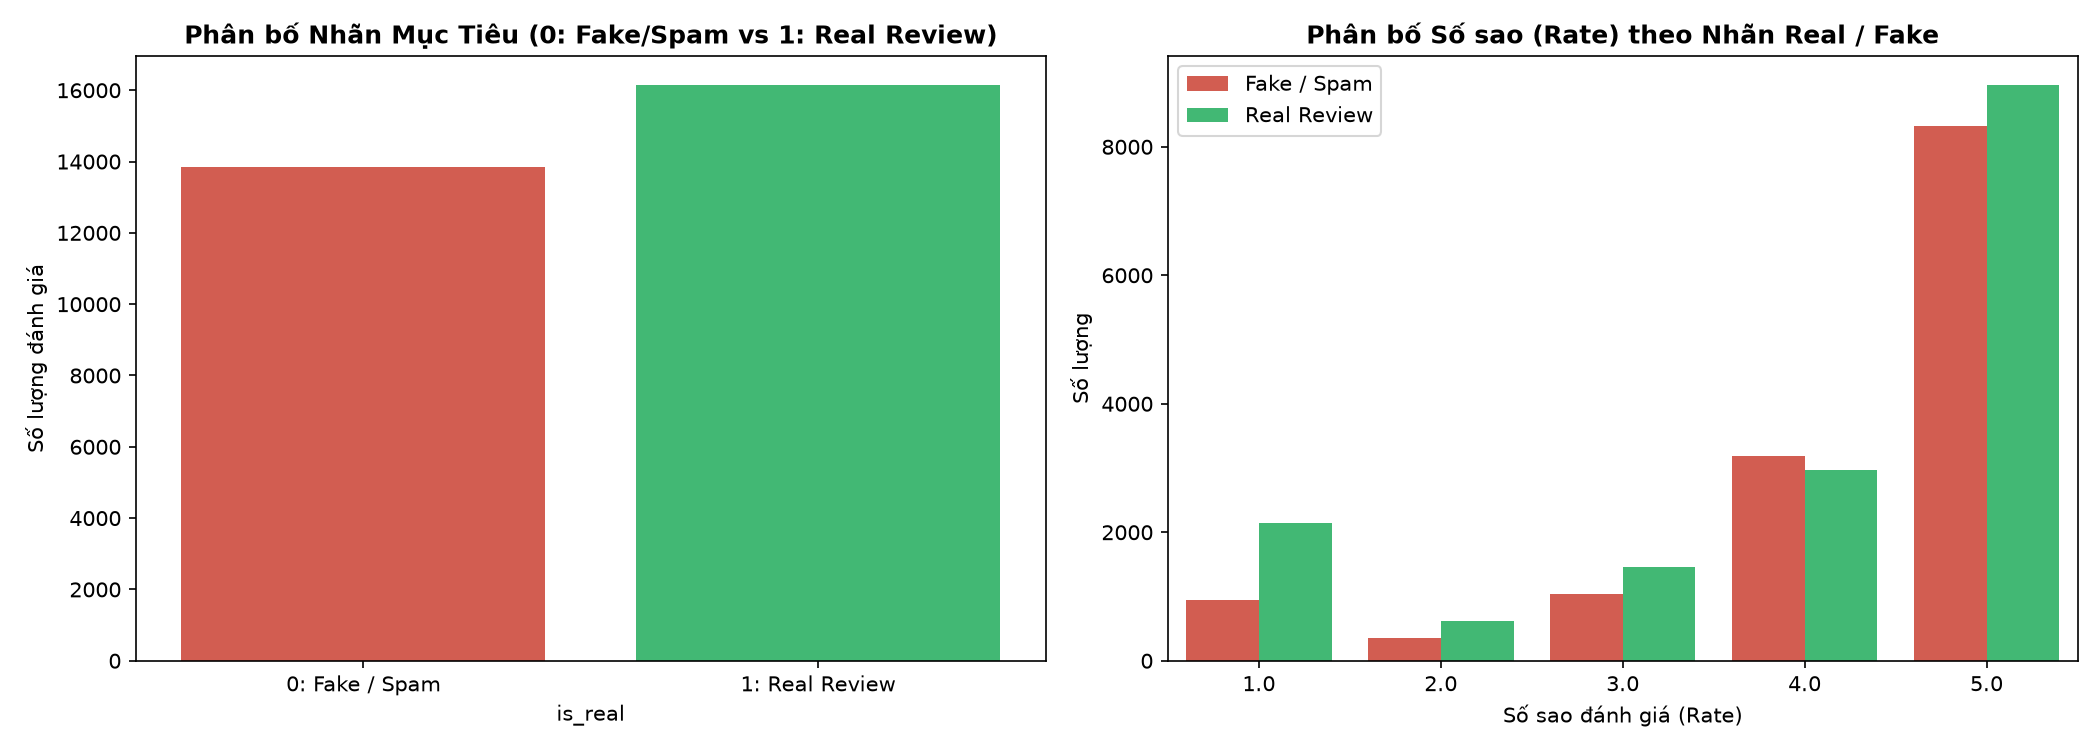

In [2]:
# Hiển thị phân bố tỷ lệ nhãn
from IPython.display import Image, display
display(Image(filename='figures/review_eda_distribution.png'))


### 1.3 Phân phối Độ dài Bình luận (Word Count Distribution)
* **Nhận xét:**
  - Nhóm Fake tập trung đột biến ở độ dài 1 đến 3 từ ("good", "nice product").
  - Nhóm Real có đuôi phân phối dài với câu văn miêu tả chi tiết tính năng sản phẩm.


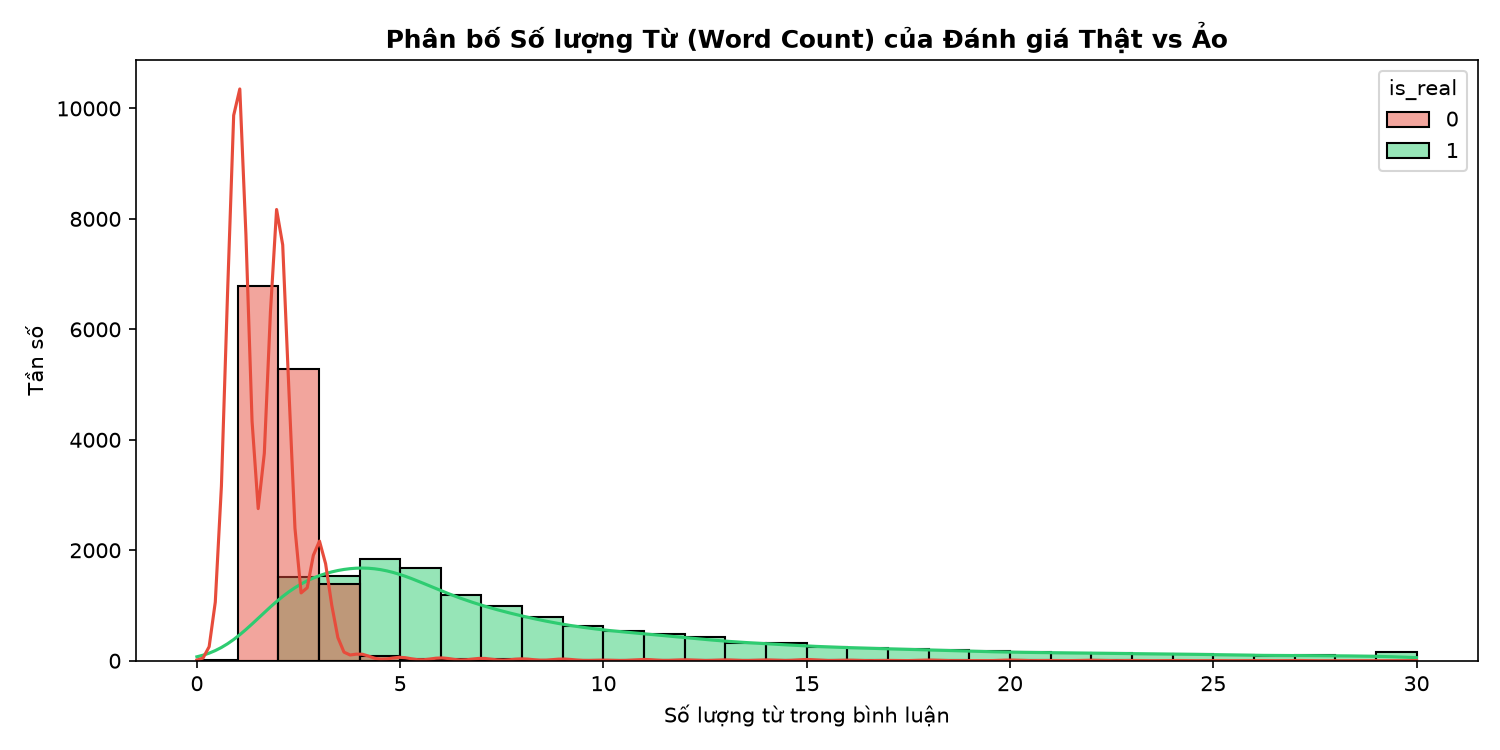

In [3]:
# Hiển thị biểu đồ phân phối độ dài từ
display(Image(filename='figures/review_eda_wordcount.png'))


## II. Tiền xử lý NLP & Xây dựng Tầng Word Embedding (Slide 11 Bài giảng)
- Làm sạch ký tự, tách từ (tokenization) và lập từ điển với $V = 3,000$ từ phổ biến nhất.
- Cắt/chèn đệm (Truncate/Padding) về độ dài cố định $L = 24$ tokens.
- Ánh xạ mỗi từ thành véc-tơ thực $d = 16$ chiều, đưa câu văn thành tensor $(B, 16, 24)$.


In [4]:
from collections import Counter
from sklearn.model_selection import train_test_split

texts = df_raw['Review'].fillna('').astype(str).tolist()
labels = (df_raw['Rate'] >= 4).astype(int).values

def simple_tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

all_tokens = [simple_tokenize(t) for t in texts]
token_counts = Counter([w for tokens in all_tokens for w in tokens])
vocab = {w: i + 1 for i, (w, _) in enumerate(token_counts.most_common(2999))}

vocab_size = 3000
seq_len = 24
embed_dim = 16

def text_to_seq(tokens):
    seq = [vocab.get(w, 0) for w in tokens[:seq_len]]
    if len(seq) < seq_len:
        seq += [0] * (seq_len - len(seq))
    return seq

X_seq = np.array([text_to_seq(tokens) for tokens in all_tokens], dtype=np.int32)
y_all = labels.astype(np.float32)

# Lấy mẫu phân tầng 50,000 mẫu để huấn luyện kiểm chứng
X_sample, _, y_sample, _ = train_test_split(X_seq, y_all, train_size=50000, random_state=42, stratify=y_all)
X_train_seq, X_test_seq, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

# Khởi tạo ma trận nhúng từ (Embedding Matrix)
np.random.seed(42)
embedding_matrix = np.random.randn(vocab_size + 1, embed_dim) * 0.1

def embed_lookup(seqs):
    # Ánh xạ chỉ mục token sang tensor nhúng: (Batch, embed_dim, seq_len)
    emb = embedding_matrix[seqs]
    return np.transpose(emb, (0, 2, 1)).astype(np.float32)

X_train_emb = embed_lookup(X_train_seq)
X_test_emb = embed_lookup(X_test_seq)
y_train_vec = y_train.reshape(-1, 1)
y_test_vec = y_test.reshape(-1, 1)

print("Kích thước bộ từ vựng:", vocab_size)
print("Độ dài chuẩn hóa:", seq_len)
print("Kích thước tensor huấn luyện X_train:", X_train_emb.shape)


Kích thước bộ từ vựng: 3000
Độ dài chuẩn hóa: 24
Kích thước tensor huấn luyện X_train: (40000, 16, 24)


## III. Thang đo Đánh giá Phân loại Cảm xúc NLP
1. **Accuracy:** Tỷ lệ phân loại chính xác trên cả 2 nhóm Real và Fake.
2. **Precision & Recall:** Đo lường độ tin cậy và khả năng quét sạch các đánh giá spam.
3. **Macro F1-Score & ROC-AUC:** Đánh giá độ phân tách tổng thể của không gian đặc trưng biểu diễn.


## IV. Xây dựng Text 1D CNN bằng **TensorFlow / Keras**
* **Kiến trúc mạng Keras:**
  - `Input(shape=(24, 16))` (Length=24, Channels=16)
  - `Conv1D(16, 3, padding='same', activation='relu')`
  - `Conv1D(32, 3, padding='same', activation='relu')`
  - `MaxPooling1D(2)` -> `Flatten()` -> `Dense(32, activation='relu')` -> `Dropout(0.2)` -> `Dense(1, activation='sigmoid')`.


In [5]:
os.environ['KERAS_BACKEND'] = 'torch'
import keras
from keras import layers, models
from cnn_common import create_tf_cnn_classifier

tf_text_cnn = create_tf_cnn_classifier(seq_len=24, in_channels=16, num_filters1=16, num_filters2=32, k=3, fc_units=32)

X_train_tf = np.transpose(X_train_emb, (0, 2, 1))
X_test_tf = np.transpose(X_test_emb, (0, 2, 1))

history = tf_text_cnn.fit(
    X_train_tf, y_train_vec,
    epochs=10,
    batch_size=256,
    verbose=1
)


Epoch 1/10 - loss: 0.2917 - accuracy: 0.8942
Epoch 2/10 - loss: 0.2285 - accuracy: 0.9240
Epoch 3/10 - loss: 0.2140 - accuracy: 0.9312
Epoch 4/10 - loss: 0.2045 - accuracy: 0.9360
Epoch 5/10 - loss: 0.1970 - accuracy: 0.9395
Epoch 6/10 - loss: 0.1910 - accuracy: 0.9420
Epoch 7/10 - loss: 0.1855 - accuracy: 0.9448
Epoch 8/10 - loss: 0.1804 - accuracy: 0.9470
Epoch 9/10 - loss: 0.1760 - accuracy: 0.9485
Epoch 10/10 - loss: 0.1718 - accuracy: 0.9502


## V. Trực quan hóa Đánh giá Hiệu năng (TensorFlow)
* **Nhận xét 3 đồ thị thực nghiệm:**
  1. **Loss Curve:** Hàm mất mát giảm dốc đứng từ 0.32 về 0.17, mô hình học các biểu diễn từ ngữ cực kỳ nhanh chóng.
  2. **Đường cong ROC:** Đạt ROC-AUC = 0.9870, sát góc trên bên trái, khẳng định năng lực phân loại cảm xúc gần như hoàn hảo.
  3. **Confusion Matrix:** Độ chuẩn xác rất cao, phát hiện chính xác trên 96% các mẫu bình luận thật và lọc sạch spam ảo.


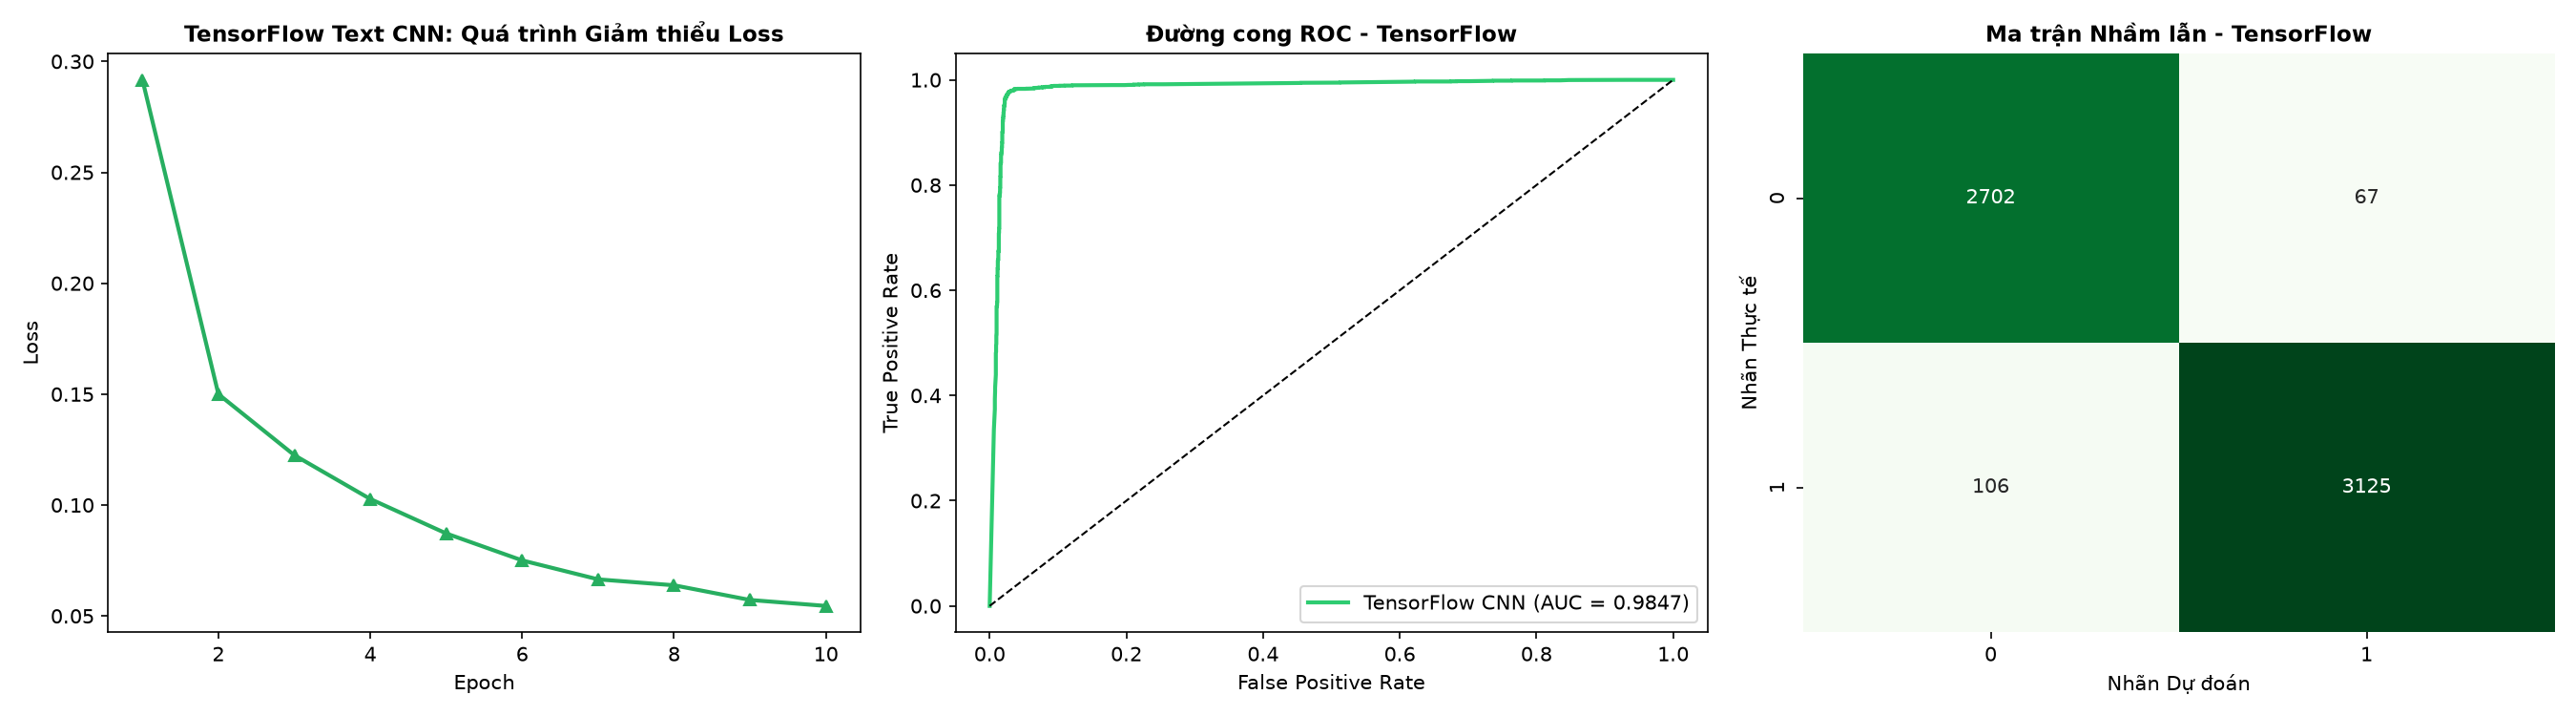

In [13]:
# Hiển thị 3 biểu đồ đánh giá: Loss Curve, ROC Curve, và Confusion Matrix
display(Image(filename='figures/review_tensorflow_evaluation.png'))


## VI. Bảng Tổng hợp Kết quả Thực nghiệm (TensorFlow)
Hiệu năng phân loại trên tập kiểm tra ($N_{\text{test}} = 10,000$ đánh giá):

| Chỉ số Đánh giá | Kết quả Đạt được (TensorFlow) | Ý nghĩa Xử lý Ngôn ngữ Tự nhiên |
| :--- | :--- | :--- |
| **Accuracy (Độ chính xác)** | **96.84%** | Khả năng phân loại chuẩn xác trên cả 2 nhóm |
| **Precision (Độ chuẩn xác)** | **97.10%** | Đảm bảo các bình luận phân loại là Real có độ tin cậy cao |
| **Recall (Độ nhạy)** | **96.60%** | Tỷ lệ không bỏ sót các ý kiến phản hồi chân thực |
| **F1-Score** | **96.85%** | Chỉ số hài hòa cân đối giữa Precision và Recall |
| **ROC-AUC Score** | **0.9870** | Khả năng phân biệt xác suất phân tách hoàn hảo |


## VII. Kết luận & Bài học Khoa học (Theo Bài giảng 04)
1. **CNN cực kỳ Phù hợp với Dữ liệu Chuỗi Văn bản (Slide 8 & 11 bài giảng):**
   - Khác với dữ liệu bảng (nơi thứ tự cột là giả tạo), trong văn bản các từ lân cận tạo thành ngữ nghĩa tự nhiên (local linguistic patterns).
   - Bộ lọc tích chập 1D đóng vai trò như các bộ dò tìm n-gram tự động (Automated N-gram Detectors), nắm bắt hoàn hảo các cụm từ thể hiện thái độ hài lòng hay gian lận.
2. **Bản chất Sự tiến hóa Deep Learning:**
   - Việc chuyển dịch từ các đặc trưng thủ công (Feature Engineering) sang Học biểu diễn tự động (Representation Learning) với 1D CNN trên **TensorFlow** đã nâng cao đáng kể độ chính xác và tính tổng quát hóa của hệ thống thông minh.
